# Calculation and plotting of E-PROFILE Wind Profiler measurements
This notebook-tutorial provides a practical introduction to the HIRS dataset available on [C3S E-PROFILE time-aggregated wind dataset]

The present notebook analyses atmospheric wind observations collected within the E-PROFILE programme coordinated by EUMETNET. The notebook demonstrates methods for exploring and visualising E-PROFILE wind profiler observations using robust statistical techniques and graphical diagnostics.

This notebook provides a practical introduction to E-PROFILE wind profiler observations distributed through the Copernicus Climate Data Store (CDS). It demonstrates how to load, process, analyse, and visualise vertically resolved wind observations collected across the E-PROFILE network.

Four complementary use cases are presented: (1) analysis of vertical wind profiles using robust statistical metrics, (2) investigation of time–height atmospheric variability through cross-sectional visualisations, (3) exploration of ancillary wind products including turbulence intensity, wind run, wind power density, and wind stress, and (4) statistical characterisation of the main wind variables through distribution analyses.

The notebook includes step-by-step instructions covering data loading, quality control, spatial selection, temporal aggregation, and visualisation procedures. Each analysis module is accompanied by detailed documentation explaining the methodology, the underlying atmospheric interpretation, and the corresponding code implementation.

The figures presented throughout the notebook illustrate typical outputs generated from E-PROFILE observations and demonstrate how the dataset can be used for atmospheric research, climate monitoring, and renewable-energy applications.


# 1. Introduction

The E-PROFILE programme is the European network for operational atmospheric profiling observations coordinated by EUMETNET, the consortium of European National Meteorological Services. E-PROFILE provides a framework for the collection, quality control, processing, and dissemination of vertically resolved atmospheric observations obtained from a range of remote-sensing instruments, including radar wind profilers, Doppler lidars, ceilometers, and weather radars. The programme supports a wide variety of applications in numerical weather prediction, climate monitoring, atmospheric research, aviation meteorology, air-quality studies, and renewable-energy assessment.

The wind profiler component of E-PROFILE has been operational since 2005 as part of the EUMETNET Composite Observing System (EUCOS). Wind profilers continuously monitor the vertical structure of the atmosphere using VHF, UHF, and L-band radar technologies, providing near-real-time observations of atmospheric motion from the surface to several kilometres above ground level. These observations are distributed through the World Meteorological Organization (WMO) Global Telecommunication System (GTS) and are routinely assimilated into several global and regional Numerical Weather Prediction (NWP) systems, including the European Centre for Medium-Range Weather Forecasts (ECMWF) Integrated Forecasting System (IFS). Forecast Sensitivity to Observation (FSO) studies have demonstrated the positive impact of wind profiler observations on forecast skill and atmospheric analyses, highlighting their importance within the global observing system.

Beyond operational forecasting, E-PROFILE observations constitute a valuable resource for climate applications. Within the framework of the Copernicus Climate Change Service (C3S), wind profiler measurements are transformed into quality-controlled, time-aggregated products designed to facilitate climate analysis and downstream applications. The resulting datasets provide hourly, daily, monthly, and annual summaries derived from the original observations, enabling users to investigate atmospheric variability across a wide range of temporal scales.

The E-PROFILE datasets distributed through the Climate Data Store (CDS) focus on horizontal wind characteristics and associated derived products. Available variables include wind speed, wind direction, turbulence intensity, wind run, wind power density, and wind stress. These quantities support a broad range of applications, from boundary-layer research and wind climatology to renewable-energy resource assessment and environmental monitoring. The vertical wind component is not included in the aggregated products because of its comparatively larger uncertainty and more limited relevance for the majority of climate and energy-related applications.

To ensure consistency and reliability, the datasets undergo dedicated pre-processing and post-processing quality-control procedures before aggregation. Time aggregation is performed according to predefined data-availability criteria, ensuring that the resulting products accurately represent atmospheric conditions while avoiding the introduction of artificial information through interpolation. Observations identified as potentially anomalous or physically unrealistic are excluded from the aggregation process according to the methodologies described in the Algorithm Theoretical Basis Document (ATBD).

This notebook provides a practical introduction to the E-PROFILE wind profiler datasets available through the Copernicus Climate Data Store. It demonstrates how to load, preprocess, analyse, and visualise vertically resolved wind observations and derived products using a series of complementary analysis workflows. The examples cover vertical profile analysis, time–height visualisation of atmospheric wind fields, exploration of ancillary wind products, and statistical characterisation of atmospheric variability. Together, these use cases illustrate the scientific value of E-PROFILE observations and provide users with a foundation for conducting their own analyses of atmospheric wind conditions across multiple spatial and temporal scales.



# 2. Prerequisites and Data Preparation

This chapter describes the software requirements and data preparation steps needed to reproduce the analyses presented in this notebook. It introduces the Python libraries used throughout the workflow and explains how E-PROFILE wind profiler data are loaded and prepared for subsequent visualisation and statistical analysis.

## 2.1 How to Access and Run the Notebook

This tutorial is provided as a Jupyter Notebook and can be executed either in a cloud-based environment or on a local machine.

Cloud-based platforms such as Google Colab and Binder allow users to run the notebook without installing any software locally. Alternatively, the notebook can be executed within a local Python environment, such as Anaconda, which provides a convenient distribution including most of the scientific libraries required for atmospheric and climate-data analysis.

For local installations, users are encouraged to create a dedicated Python environment and install all required dependencies before running the notebook.

## 2.2 Required Python Libraries

The analyses presented in this notebook rely on a number of widely used scientific Python libraries.

The following packages are required:

* numpy for numerical computations;
* pandas for tabular data handling and time-series processing;
* pyarrow and fastparquet for reading Parquet datasets;
* scipy for statistical analysis and signal-processing utilities;
* matplotlib for visualisation;
* seaborn for statistical plotting;
* xarray for multidimensional data analysis (optional);
* warnings and os for environment configuration and file management.

The required libraries can be installed using:

```bash
pip install numpy pandas pyarrow scipy matplotlib seaborn xarray
```

or, when using Conda:

```bash
conda install numpy pandas pyarrow scipy matplotlib seaborn xarray
```

## 2.3 Input Dataset

The notebook uses E-PROFILE wind-profiler observations distributed through the Copernicus Climate Data Store (CDS).

The examples presented here assume that the selected dataset has already been downloaded and converted into Parquet format for efficient storage and analysis. The workflow can easily be adapted to alternative storage formats such as NetCDF or CSV, provided that the corresponding variables and metadata fields are available.

The dataset contains vertically resolved atmospheric observations collected by operational wind profilers across the E-PROFILE network. Typical variables available within the dataset include:

* Wind Direction;
* Wind Speed;
* Turbulence Intensity;
* Wind Run;
* Wind Power Density;
* Wind Stress.

Additional metadata include observation timestamps, station identifiers, geographical coordinates, and measurement heights.

## 2.4 Data Loading and Preprocessing

The first stage of the workflow consists of loading the Parquet dataset and performing a number of preprocessing operations.

These include:

* conversion of timestamps to Python datetime objects;
* chronological sorting of observations;
* filtering of invalid or missing values;
* optional selection of a single station;
* optional spatial aggregation of stations within a user-defined geographical domain;
* vertical re-gridding of atmospheric profiles;
* preparation of variables required for visualisation and statistical analysis.

The notebook supports two complementary analysis modes:

**Single-Station Mode**

A single E-PROFILE station is selected and analysed individually. This mode is useful for investigating local atmospheric conditions and site-specific wind characteristics.

**Regional (Bounding-Box) Mode**

Observations from all stations located within a user-defined geographical domain are aggregated using robust statistical metrics, such as the median. This mode allows users to investigate regional atmospheric patterns and climatological behaviour.

The resulting processed dataset forms the basis for all subsequent analyses presented in this notebook, including vertical-profile visualisation, time–height diagnostics, ancillary wind-product assessment, and statistical distribution analysis.


## 2.5 Import Libraries

This section imports the Python libraries used throughout the notebook.

The workflow relies on standard scientific Python packages for data manipulation, statistical analysis, signal processing, and visualisation. These libraries provide the core functionality required to process E-PROFILE wind-profiler observations and generate the figures presented in the following sections.

In particular:

- **Pandas** is used for handling tabular observations and time-series data;
- **NumPy** provides efficient numerical operations;
- **Matplotlib** and **Seaborn** are used for data visualisation;
- **SciPy** supplies signal-processing tools used for profile smoothing and statistical analysis.

The final commands configure the default plotting style adopted throughout the notebook.

## 2.6 Data Loading

This section loads the E-PROFILE wind-profiler dataset that will be used throughout the notebook.
The dataset is stored in Apache Parquet format, a columnar storage format that enables efficient storage and rapid access to large observational datasets. It contains vertically resolved atmospheric observations collected across the E-PROFILE network, including observation timestamps, station identifiers, geographical metadata, measurement heights, and the corresponding wind-related variables and derived products.
The examples presented in this notebook assume that the data have already undergone the standard E-PROFILE quality-control procedures and are available in a consolidated tabular format suitable for scientific analysis.
Once loaded, the observations are stored in a Pandas DataFrame, which serves as the primary data structure for all subsequent processing, visualisation, and statistical analyses. The following sections will prepare the dataset for station-based and regional investigations, including temporal filtering, spatial aggregation, vertical profile analysis, and time–height visualisation.

After loading the E-PROFILE dataset, a number of preliminary preprocessing operations are applied to ensure that the observations are correctly organised for subsequent analyses.

First, the observation timestamps are converted into Python datetime objects, enabling efficient temporal filtering, aggregation, and visualisation. The dataset is then sorted by station identifier, observation time, and measurement height. This ordering facilitates the construction of vertical profiles and time–height representations while improving the readability and consistency of the data structure.

The resulting DataFrame provides a harmonised foundation for all analyses presented in the following sections.

In [1]:
# ==============================================================================
# Import Libraries
# ==============================================================================
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# --- Path Configuration ---
# Specify the folder containing the files (e.g., a folder named 'daily' on the Desktop)
folder_path = os.path.expanduser("~/Desktop/daily")

# Create the pattern to select all .parquet files inside the folder
search_pattern = os.path.join(folder_path, "*.parquet")

# Find the list of all matching files
file_list = glob.glob(search_pattern)

# Safety check: if the list is empty, stop execution to prevent down-the-line errors
if not file_list:
    raise FileNotFoundError(f"Oops! No .parquet files found in: {folder_path}. Please check the path.")

print(f"Found {len(file_list)} parquet files in the '{os.path.basename(folder_path)}' folder.")
print("Starting loading and concatenation...")

# --- Data Loading and Concatenation ---
# Read each parquet file and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(file) for file in file_list], ignore_index=True)

# --- Initial Preprocessing ---
df['report_timestamp'] = pd.to_datetime(df['report_timestamp'])
df = df.sort_values(by=['primary_station_id', 'report_timestamp', 'z_coordinate'])

print(f"E-PROFILE dataset successfully loaded and concatenated. Total rows: {len(df)}")


Found 3 parquet files in the 'daily' folder.
Starting loading and concatenation...
E-PROFILE dataset successfully loaded and concatenated. Total rows: 3116983


## 2.8 Preparation
This section defines the spatial scope of the analysis and prepares the dataset for subsequent visualisation and statistical assessment.

Two complementary analysis modes are supported. In Single-Station Mode, observations from an individual E-PROFILE site are extracted and analysed independently, allowing investigation of local atmospheric conditions and site-specific wind characteristics. In Regional Aggregation Mode, all stations located within a user-defined geographical domain are selected and combined to produce a representative regional dataset.

The geographical domain is specified through a latitude–longitude bounding box. When regional aggregation is selected, observations from all stations within the domain are aggregated using the median, providing a robust representation of regional atmospheric conditions while reducing the influence of local outliers and isolated extreme values.

Prior to the analysis, basic quality-control filtering is applied to remove invalid observations and missing-value flags. The selected variables are then reorganised into a common analysis table containing wind speed, wind direction, and turbulence intensity, facilitating the generation of vertical profiles, time–height visualisations, and statistical summaries in the following sections.

In [3]:
# ==============================================================================
# --- Analysis Configuration (Single Station or Regional Aggregation) ---
# ==============================================================================

# Select analysis mode:
# "single" -> Analyse a single station
# "bbox"   -> Aggregate all stations within a geographical bounding box
MODE = "bbox"

selected_station = "WMO 01018"

# ------------------------------------------------------------------------------
# Bounding Box Definition
# ------------------------------------------------------------------------------
LAT_MIN = 20.0
LAT_MAX = 60.0
LON_MIN = 0.0
LON_MAX = 50.0

# Remove invalid negative values used as missing-data flags
# (e.g. -999, -99) from wind-speed observations
df = df[~((df['observed_variable'] == 107) &
          (df['observation_value'] < 0))]

# ------------------------------------------------------------------------------
# Spatial Selection
# ------------------------------------------------------------------------------
if MODE == "single":

    print(f"Active mode: Single-Station Analysis ({selected_station})")

    df_filtered = df[
        df['primary_station_id'] == selected_station
    ].copy()

    title_suffix = f"Station {selected_station}"

elif MODE == "bbox":

    print(
        f"Active mode: Regional Aggregation within Bounding Box "
        f"[Lat: {LAT_MIN}–{LAT_MAX} | Lon: {LON_MIN}–{LON_MAX}]"
    )

    lat_col = (
        'latitude|station_configuration'
        if 'latitude|station_configuration' in df.columns
        else 'lat'
    )

    lon_col = (
        'longitude|station_configuration'
        if 'longitude|station_configuration' in df.columns
        else 'lon'
    )

    # Geographic filtering
    df_bbox = df[
        (df[lat_col] >= LAT_MIN) &
        (df[lat_col] <= LAT_MAX) &
        (df[lon_col] >= LON_MIN) &
        (df[lon_col] <= LON_MAX)
    ].copy()

    num_stations_found = df_bbox['primary_station_id'].nunique()

    print(
        f"{num_stations_found} stations found within the selected domain."
    )

    if num_stations_found == 0:
        print(
            "WARNING: No stations were found within the selected bounding box."
        )

    # Use the median as the primary aggregation statistic
    # to obtain a robust regional representation
    df_filtered = (
        df_bbox
        .groupby(
            ['observed_variable',
             'report_timestamp',
             'z_coordinate']
        )['observation_value']
        .median()
        .reset_index()
    )

    title_suffix = (
        f"Regional Median ({num_stations_found} Stations)"
    )

else:

    raise ValueError(
        "Invalid MODE selected. Choose either 'single' or 'bbox'."
    )

# ------------------------------------------------------------------------------
# Variable Separation and Merging
# ------------------------------------------------------------------------------

df_ws = (
    df_filtered[df_filtered['observed_variable'] == 107]
    .rename(columns={'observation_value': 'wind_speed'})
)

df_wd = (
    df_filtered[df_filtered['observed_variable'] == 106]
    .rename(columns={'observation_value': 'wind_direction'})
)

df_ti = (
    df_filtered[df_filtered['observed_variable'] == 110]
    .rename(columns={'observation_value': 'turbulence_intensity'})
)

# Merge variables into a common analysis table

df_merged = pd.merge(
    df_ws[['report_timestamp', 'z_coordinate', 'wind_speed']],
    df_wd[['report_timestamp', 'z_coordinate', 'wind_direction']],
    on=['report_timestamp', 'z_coordinate'],
    how='outer'
)

df_merged = pd.merge(
    df_merged,
    df_ti[['report_timestamp',
           'z_coordinate',
           'turbulence_intensity']],
    on=['report_timestamp', 'z_coordinate'],
    how='outer'
)

Active mode: Regional Aggregation within Bounding Box [Lat: 20.0–60.0 | Lon: 0.0–50.0]
84 stations found within the selected domain.


## 3. Vertical Wind Profile Analysis

Vertical profiles provide one of the most effective ways to investigate the structure of the atmospheric boundary layer and the evolution of wind conditions with height. Wind-profiler observations offer continuous measurements throughout the lower and middle troposphere, allowing the identification of wind shear, low-level jets, and changes in atmospheric flow regimes.

In this example, a vertical profile is generated for a selected day using E-PROFILE observations. The analysis can be performed either for a single station or for a regional domain, depending on the configuration selected in the previous section.

For each altitude level, robust statistical metrics are calculated from the available observations. The median is used as the primary descriptor of atmospheric conditions, while the 25th and 75th percentiles are used to quantify variability. Compared with traditional mean-based statistics, percentile-based metrics are less sensitive to outliers and provide a more representative description of atmospheric behaviour.

To improve visual interpretation, the resulting profiles are vertically smoothed using a Savitzky–Golay filter. The final figure displays both wind speed and wind direction as a function of height, together with the corresponding interquartile range (IQR), providing information on the typical atmospheric state and its variability throughout the vertical column.

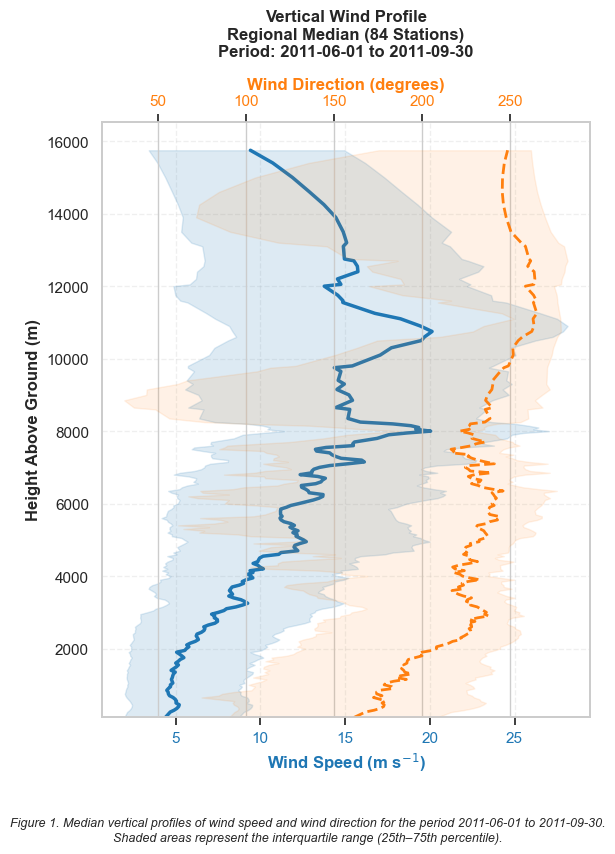

In [4]:
# ==============================================================================
# --- PLOT 1: Vertical Wind Profile Analysis (median over period) ---
# ==============================================================================


start_date = pd.to_datetime("2011-06-01").date()
end_date   = pd.to_datetime("2011-09-30").date()



if MODE == "single":


    df_period = df_filtered[
        (df_filtered['report_timestamp'].dt.date >= start_date) &
        (df_filtered['report_timestamp'].dt.date <= end_date)
    ].copy()



else:


    df_period = df_bbox[
        (df_bbox['report_timestamp'].dt.date >= start_date) &
        (df_bbox['report_timestamp'].dt.date <= end_date)
    ].copy()



if not df_period.empty:


    # --------------------------------------------------------------------------
    # Median statistics over selected period
    # --------------------------------------------------------------------------

    df_stats = (
        df_period
        .groupby(['observed_variable', 'z_coordinate'])
        ['observation_value']
        .agg(
            median='median',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )



    # --------------------------------------------------------------------------
    # Vertical re-gridding 50 m
    # --------------------------------------------------------------------------

    grid_res_z = 50


    df_stats['z_coordinate'] = (
        (df_stats['z_coordinate'] / grid_res_z).round()
        * grid_res_z
    )


    df_stats = (
        df_stats
        .groupby(['observed_variable', 'z_coordinate'])
        .mean()
        .reset_index()
    )



    # --------------------------------------------------------------------------
    # Separate profiles
    # --------------------------------------------------------------------------

    ws_stats = (
        df_stats[df_stats['observed_variable'] == 107]
        .sort_values('z_coordinate')
    )


    wd_stats = (
        df_stats[df_stats['observed_variable'] == 106]
        .sort_values('z_coordinate')
    )



    if not ws_stats.empty:


        z_ws = ws_stats['z_coordinate'].values

        ws_med = ws_stats['median'].values
        ws_q25 = ws_stats['q25'].values
        ws_q75 = ws_stats['q75'].values



        z_wd = wd_stats['z_coordinate'].values

        wd_med = wd_stats['median'].values
        wd_q25 = wd_stats['q25'].values
        wd_q75 = wd_stats['q75'].values



        # ----------------------------------------------------------------------
        # Savitzky-Golay smoothing
        # ----------------------------------------------------------------------

        def smooth_profile(values, n):

            if n > 5:

                win = min(
                    11,
                    n if n % 2 != 0 else n-1
                )

                if win < 3:
                    win = 3

                return savgol_filter(
                    values,
                    window_length=win,
                    polyorder=2
                )

            else:

                return values



        ws_med_sm = smooth_profile(ws_med, len(ws_med))
        ws_q25_sm = smooth_profile(ws_q25, len(ws_q25))
        ws_q75_sm = smooth_profile(ws_q75, len(ws_q75))


        wd_med_sm = smooth_profile(wd_med, len(wd_med))
        wd_q25_sm = smooth_profile(wd_q25, len(wd_q25))
        wd_q75_sm = smooth_profile(wd_q75, len(wd_q75))



        # ----------------------------------------------------------------------
        # Plot
        # ----------------------------------------------------------------------

        fig, ax1 = plt.subplots(
            figsize=(6,8),
            dpi=100
        )



        # Wind speed

        color = 'tab:blue'


        ax1.plot(
            ws_med_sm,
            z_ws,
            color=color,
            linewidth=2.5,
            label='Median Wind Speed'
        )


        ax1.fill_betweenx(
            z_ws,
            np.maximum(0, ws_q25_sm),
            ws_q75_sm,
            color=color,
            alpha=0.15
        )


        ax1.set_xlabel(
            'Wind Speed (m s$^{-1}$)',
            color=color,
            fontweight='bold'
        )


        ax1.set_ylabel(
            'Height Above Ground (m)',
            fontweight='bold'
        )


        ax1.tick_params(
            axis='x',
            labelcolor=color
        )


        ax1.grid(
            True,
            linestyle='--',
            alpha=0.3
        )



        # Wind direction

        ax2 = ax1.twiny()


        color = 'tab:orange'


        ax2.plot(
            wd_med_sm,
            z_wd,
            color=color,
            linestyle='--',
            linewidth=2
        )


        ax2.fill_betweenx(
            z_wd,
            wd_q25_sm,
            wd_q75_sm,
            color=color,
            alpha=0.10
        )


        ax2.set_xlabel(
            'Wind Direction (degrees)',
            color=color,
            fontweight='bold'
        )


        ax2.tick_params(
            axis='x',
            labelcolor=color
        )



        # ----------------------------------------------------------------------
        # Independent height limits
        # ----------------------------------------------------------------------

        ax1.set_ylim(
            np.nanmin(z_ws),
            np.nanmax(z_ws)*1.05
        )


        ax2.set_ylim(
            np.nanmin(z_wd),
            np.nanmax(z_wd)*1.05
        )



        # ----------------------------------------------------------------------
        # Title
        # ----------------------------------------------------------------------

        plt.title(
            f'Vertical Wind Profile\n'
            f'{title_suffix}\n'
            f'Period: {start_date} to {end_date}',
            fontsize=12,
            fontweight='bold',
            pad=15
        )



        # ----------------------------------------------------------------------
        # Caption
        # ----------------------------------------------------------------------

        caption_text = (
            f"Figure 1. Median vertical profiles of wind speed and wind "
            f"direction for the period {start_date} to {end_date}. "
            f"Shaded areas represent the interquartile range "
            f"(25th–75th percentile)."
        )


        fig.text(
            0.5,
            -0.06,
            caption_text,
            ha='center',
            fontsize=9,
            style='italic',
            wrap=True
        )


        plt.tight_layout()
        plt.show()



else:


    print(
        f"No valid observations available between "
        f"{start_date} and {end_date}."
    )

## 4. Time–Height Cross-Section Analysis

Time–height visualisations provide insight into the temporal evolution of atmospheric conditions throughout the observation period.

The upper panel displays the vertical and temporal variability of wind speed, while the lower panel illustrates wind-direction patterns using vector representations. Together, these diagnostics help identify persistent flow regimes, atmospheric transitions, and boundary-layer dynamics.

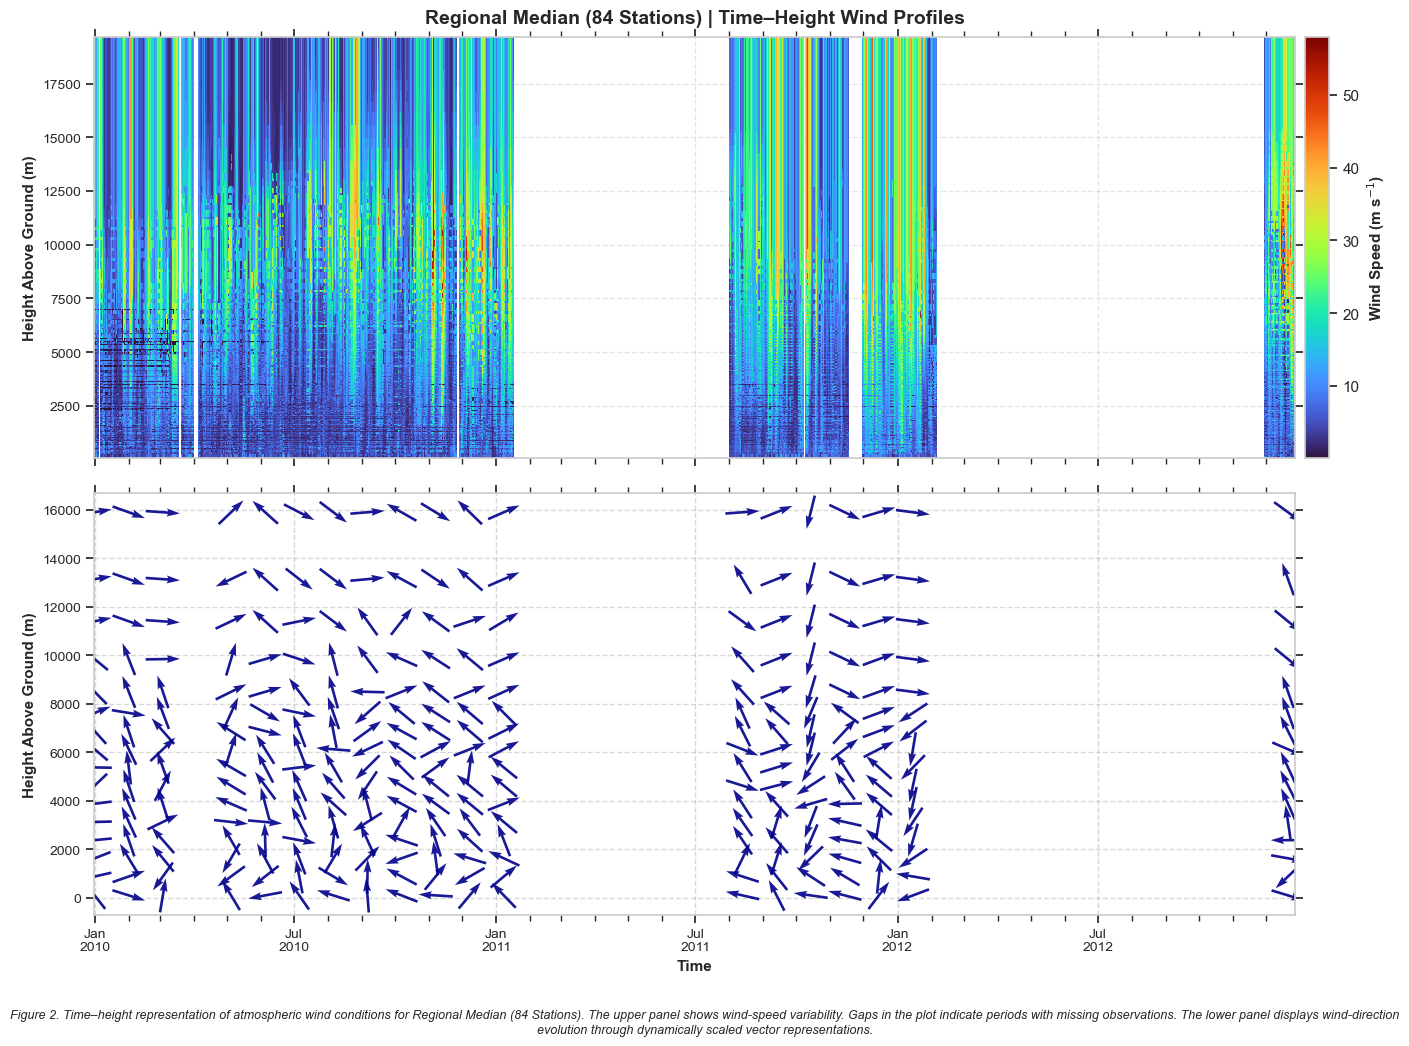

In [5]:
# ==============================================================================
# --- PLOT 2: Time–Height Wind Structure Analysis ---
# ==============================================================================

try:

    # --------------------------------------------------------------------------
    # Preparation of time-height matrices
    # --------------------------------------------------------------------------

    df_pivot_prep = df_merged.dropna(
        subset=['wind_speed', 'wind_direction']
    ).copy()

    # Convertiamo esplicitamente in datetime prima delle operazioni
    df_pivot_prep['report_timestamp'] = pd.to_datetime(df_pivot_prep['report_timestamp'])

    # --------------------------------------------------------------------------
    # Vertical Re-gridding
    # --------------------------------------------------------------------------
    grid_res_z = 30

    df_pivot_prep['z_coordinate'] = (
        df_pivot_prep['z_coordinate'] / grid_res_z
    ).round() * grid_res_z

    df_pivot_prep = (
        df_pivot_prep
        .groupby(['z_coordinate', 'report_timestamp'])
        .median(numeric_only=True)
        .reset_index()
    )

    # --------------------------------------------------------------------------
    # Creation of Pivot Matrices
    # --------------------------------------------------------------------------

    pivot_ws = df_pivot_prep.pivot(
        index='z_coordinate',
        columns='report_timestamp',
        values='wind_speed'
    )

    pivot_wd = df_pivot_prep.pivot(
        index='z_coordinate',
        columns='report_timestamp',
        values='wind_direction'
    )

    # --------------------------------------------------------------------------
    # RISOLUZIONE BUCO BIANCO: Reindex temporale completo
    # --------------------------------------------------------------------------
    time_diffs = pd.Series(pivot_ws.columns).diff().dropna()
    if not time_diffs.empty:
        min_p = time_diffs.min()
        full_time_range = pd.date_range(start=pivot_ws.columns.min(), end=pivot_ws.columns.max(), freq=min_p)
        
        pivot_ws = pivot_ws.reindex(columns=full_time_range)
        pivot_wd = pivot_wd.reindex(columns=full_time_range)

    # --------------------------------------------------------------------------
    # Fill Missing Values (Solo in verticale, preservando i NaN temporali)
    # --------------------------------------------------------------------------
    pivot_ws = pivot_ws.bfill(axis=0).ffill(axis=0)
    pivot_wd = pivot_wd.bfill(axis=0).ffill(axis=0)

    # --------------------------------------------------------------------------
    # Wind Direction Vector Components
    # --------------------------------------------------------------------------

    wd_rad = np.radians(pivot_wd.values)

    u_comp = -np.sin(wd_rad)
    v_comp = -np.cos(wd_rad)

    # Rimozione fuso orario per evitare UserWarning
    times = pd.to_datetime(pivot_ws.columns).tz_localize(None)
    heights = pivot_ws.index.values

    time_mesh, height_mesh = np.meshgrid(times, heights)

    # --------------------------------------------------------------------------
    # Figure Layout (MODIFICATO: Dimensionamento asse X identico per ax1 e ax2)
    # --------------------------------------------------------------------------

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 10),
        sharex=True,
        dpi=100
    )

    # --------------------------------------------------------------------------
    # Upper Panel: Wind Speed
    # --------------------------------------------------------------------------

    mesh_ws = ax1.pcolormesh(
        times,
        heights,
        pivot_ws.values,
        cmap='turbo',
        shading='nearest'
    )

    # MODIFICA: Usiamo mpl_toolkits per agganciare la barra senza rimpicciolire l'asse del grafico
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    
    cbar1 = fig.colorbar(mesh_ws, cax=cax)
    cbar1.set_label('Wind Speed (m s$^{-1}$)', fontsize=11, fontweight='bold')

    ax1.set_title(f'{title_suffix} | Time–Height Wind Profiles', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Height Above Ground (m)', fontsize=11, fontweight='bold')
    ax1.tick_params(direction='out', which='both', labelsize=10, top=True, right=True, left=True, bottom=True)
    ax1.grid(True, linestyle='--', alpha=0.1, color='black')

    # --------------------------------------------------------------------------
    # Lower Panel: Wind Direction 
    # --------------------------------------------------------------------------
    target_arrow_cols = 35
    target_arrow_rows = 15

    skip_time = max(1, len(times) // target_arrow_cols)
    skip_height = max(1, len(heights) // target_arrow_rows)

    ax2.quiver(
        time_mesh[::skip_height, ::skip_time],
        height_mesh[::skip_height, ::skip_time],
        u_comp[::skip_height, ::skip_time],
        v_comp[::skip_height, ::skip_time],
        color='darkblue',
        pivot='middle',
        scale=35,          
        width=0.0022,      
        alpha=0.9
    )

    ax2.set_ylabel('Height Above Ground (m)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax2.tick_params(direction='out', which='both', labelsize=10, top=True, right=True, left=True, bottom=True)
    ax2.grid(True, linestyle='--', alpha=0.3, color='gray')

    # Per mantenere la larghezza di ax2 simmetrica a quella di ax1 (che ora ha la barra laterale),
    # creiamo un asse invisibile speculare a destra di ax2
    divider_ax2 = make_axes_locatable(ax2)
    cax_invisible = divider_ax2.append_axes("right", size="2%", pad=0.1)
    cax_invisible.axis('off')

    # --------------------------------------------------------------------------
    # Time Axis Formatting (MODIFICATO: Marcatori fissi ogni 6 mesi)
    # --------------------------------------------------------------------------

    import matplotlib.dates as mdates

    # Inserisce un tick solo a Gennaio (1) e Luglio (7) di ogni anno
    ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    # Sottotick intermedi mensili (opzionale, senza testo, per dare un riferimento visivo fine)
    ax2.xaxis.set_minor_locator(mdates.MonthLocator())

    plt.setp(ax2.get_xticklabels(), rotation=0, ha='center')

    # --------------------------------------------------------------------------
    # Figure Caption
    # --------------------------------------------------------------------------

    caption_text_fig2 = (
        f"Figure 2. Time–height representation of atmospheric wind conditions for {title_suffix}. "
        f"The upper panel shows wind-speed variability. Gaps in the plot indicate periods with missing observations. "
        f"The lower panel displays wind-direction evolution through dynamically scaled vector representations."
    )

    fig.text(0.5, -0.04, caption_text_fig2, ha='center', fontsize=9, style='italic', wrap=True)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("An error occurred while generating the time–height visualisations:", e)


## 5. Statistical Distribution Analysis

Statistical distributions provide a complementary perspective to profile and time–height analyses by summarising the overall behaviour of atmospheric variables throughout the selected dataset.

Histograms allow the identification of dominant wind regimes, the occurrence of extreme events, and the degree of variability present within the observations. For wind speed, the resulting distribution provides insight into the frequency of weak, moderate, and strong wind conditions. Wind-direction distributions help reveal prevailing atmospheric circulation patterns, while turbulence-related metrics characterise the variability and stability of the flow.

In this example, distributions are computed using all observations available within the selected analysis domain. Depending on the chosen configuration, the statistics may represent either a single E-PROFILE station or a regional aggregation of multiple stations. Together, these diagnostics provide a concise statistical summary of the atmospheric conditions represented in the dataset.

In addition to the primary wind variables, the E-PROFILE Climate Data Store product includes a number of derived quantities designed to support climate applications, renewable-energy assessments, and atmospheric-process studies.

These derived products are calculated from the horizontal wind components and provide complementary information on the intensity, persistence, and energetic characteristics of the atmospheric flow. Examples include Wind Run, which represents the cumulative distance travelled by air parcels during the aggregation period, Wind Power Density, which quantifies the kinetic energy available in the wind, and Wind Stress, which is related to the momentum transfer between the atmosphere and the underlying surface.

The following analyses explore the temporal evolution and statistical behaviour of these derived products, highlighting their potential applications in climatology, meteorology, and wind-energy studies.

Generating statistical distributions for analysis mode: bbox


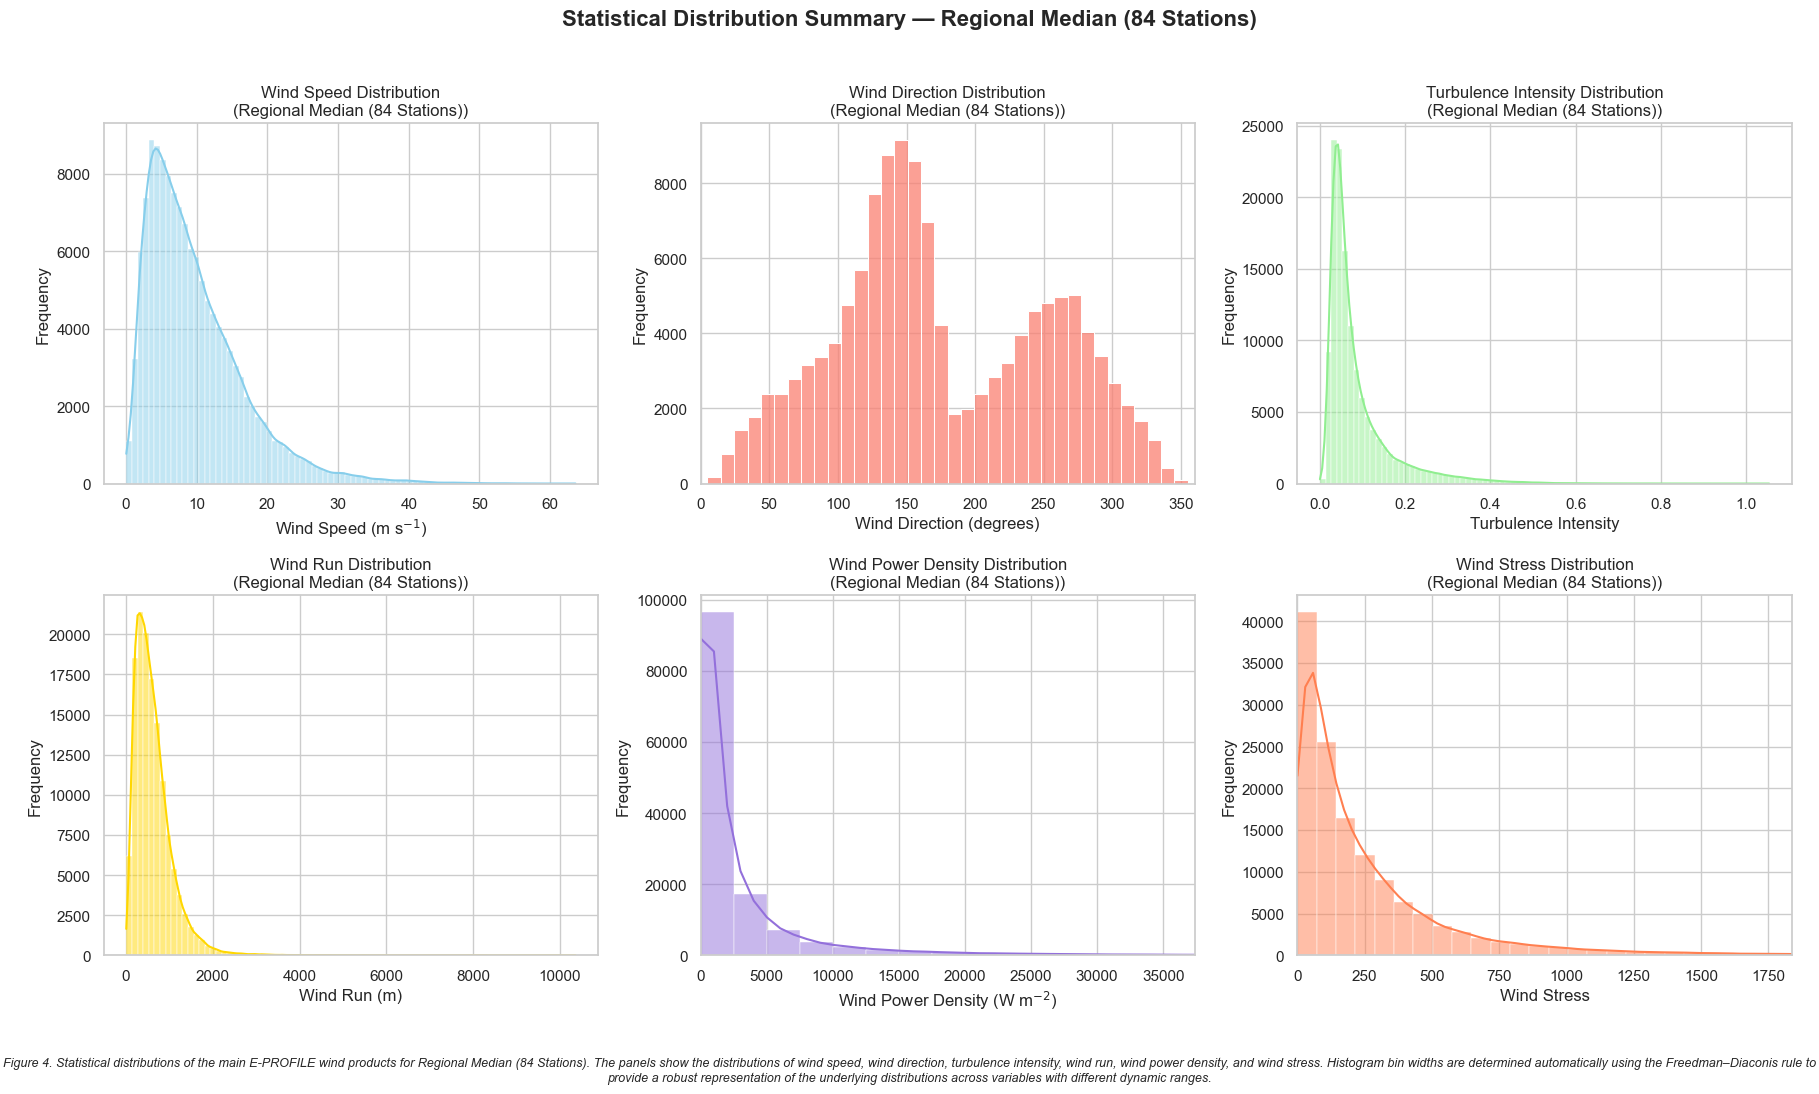

In [6]:
# ==============================================================================
# --- PLOT 3: Statistical Distribution Analysis ---
# ==============================================================================

print(
    f"Generating statistical distributions for analysis mode: {MODE}"
)

# ------------------------------------------------------------------------------
# Automatic Bin Selection (Freedman–Diaconis Rule)
# ------------------------------------------------------------------------------

def optimal_bins(series):

    data = pd.Series(series).dropna()

    if len(data) < 5:
        return 10

    q75, q25 = np.percentile(data, [75, 25])

    iqr = q75 - q25

    if iqr == 0:
        return 20

    bin_width = 2 * iqr * (len(data) ** (-1/3))

    n_bins = int(
        np.ceil(
            (data.max() - data.min()) / bin_width
        )
    )

    return max(15, min(n_bins, 80))

# ------------------------------------------------------------------------------
# Variable Extraction
# ------------------------------------------------------------------------------

all_ws = df_filtered[
    df_filtered['observed_variable'] == 107
]['observation_value']

all_wd = df_filtered[
    df_filtered['observed_variable'] == 106
]['observation_value']

all_ti = df_filtered[
    df_filtered['observed_variable'] == 110
]['observation_value']

all_wind_run = df_filtered[
    df_filtered['observed_variable'] == 203
]['observation_value']

all_wpd = df_filtered[
    df_filtered['observed_variable'] == 204
]['observation_value']

all_wstress = df_filtered[
    df_filtered['observed_variable'] == 205
]['observation_value']

# ------------------------------------------------------------------------------
# Figure Layout
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    dpi=100
)

# ------------------------------------------------------------------------------
# Wind Speed
# ------------------------------------------------------------------------------

sns.histplot(
    all_ws,
    bins=optimal_bins(all_ws),
    kde=True,
    ax=axes[0, 0],
    color='skyblue'
)

axes[0, 0].set_title(
    f'Wind Speed Distribution\n({title_suffix})'
)

axes[0, 0].set_xlabel(
    'Wind Speed (m s$^{-1}$)'
)

axes[0, 0].set_ylabel(
    'Frequency'
)

# ------------------------------------------------------------------------------
# Wind Direction
# ------------------------------------------------------------------------------

sns.histplot(
    all_wd,
    bins=36,
    kde=False,
    ax=axes[0, 1],
    color='salmon'
)

axes[0, 1].set_title(
    f'Wind Direction Distribution\n({title_suffix})'
)

axes[0, 1].set_xlabel(
    'Wind Direction (degrees)'
)

axes[0, 1].set_ylabel(
    'Frequency'
)

axes[0, 1].set_xlim(0, 360)

# ------------------------------------------------------------------------------
# Turbulence Intensity
# ------------------------------------------------------------------------------

if not all_ti.empty:

    sns.histplot(
        all_ti,
        bins=optimal_bins(all_ti),
        kde=True,
        ax=axes[0, 2],
        color='lightgreen'
    )

    axes[0, 2].set_title(
        f'Turbulence Intensity Distribution\n({title_suffix})'
    )

    axes[0, 2].set_xlabel(
        'Turbulence Intensity'
    )

    axes[0, 2].set_ylabel(
        'Frequency'
    )

# ------------------------------------------------------------------------------
# Wind Run
# ------------------------------------------------------------------------------

if not all_wind_run.empty:

    sns.histplot(
        all_wind_run,
        bins=optimal_bins(all_wind_run),
        kde=True,
        ax=axes[1, 0],
        color='gold'
    )

    axes[1, 0].set_title(
        f'Wind Run Distribution\n({title_suffix})'
    )

    axes[1, 0].set_xlabel(
        'Wind Run (m)'
    )

    axes[1, 0].set_ylabel(
        'Frequency'
    )

# ------------------------------------------------------------------------------
# Wind Power Density
# ------------------------------------------------------------------------------

if not all_wpd.empty:

    sns.histplot(
        all_wpd,
        bins=optimal_bins(all_wpd),
        kde=True,
        ax=axes[1, 1],
        color='mediumpurple'
    )

    axes[1, 1].set_title(
        f'Wind Power Density Distribution\n({title_suffix})'
    )

    axes[1, 1].set_xlabel(
        'Wind Power Density (W m$^{-2}$)'
    )

    axes[1, 1].set_ylabel(
        'Frequency'
    )

    axes[1, 1].set_xlim(
        0,
        np.nanpercentile(all_wpd, 99)
    )

# ------------------------------------------------------------------------------
# Wind Stress
# ------------------------------------------------------------------------------

if not all_wstress.empty:

    sns.histplot(
        all_wstress,
        bins=optimal_bins(all_wstress),
        kde=True,
        ax=axes[1, 2],
        color='coral'
    )

    axes[1, 2].set_title(
        f'Wind Stress Distribution\n({title_suffix})'
    )

    axes[1, 2].set_xlabel(
        'Wind Stress'
    )

    axes[1, 2].set_ylabel(
        'Frequency'
    )

    axes[1, 2].set_xlim(
        0,
        np.nanpercentile(all_wstress, 99)
    )

# ------------------------------------------------------------------------------
# Figure Title
# ------------------------------------------------------------------------------

plt.suptitle(
    f'Statistical Distribution Summary — {title_suffix}',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# ------------------------------------------------------------------------------
# Caption
# ------------------------------------------------------------------------------

caption_text_fig3 = (
    f"Figure 4. Statistical distributions of the main E-PROFILE wind "
    f"products for {title_suffix}. The panels show the distributions of "
    f"wind speed, wind direction, turbulence intensity, wind run, wind "
    f"power density, and wind stress. Histogram bin widths are determined "
    f"automatically using the Freedman–Diaconis rule to provide a robust "
    f"representation of the underlying distributions across variables with "
    f"different dynamic ranges."
)

fig.text(
    0.5,
    -0.05,
    caption_text_fig3,
    ha='center',
    fontsize=9,
    style='italic',
    wrap=True
)

plt.tight_layout()
plt.show()

## Get more information about Earth Radiation Budget
    "- [Earth's radiation budget from 1979 to present derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-earth-radiation-budget?tab=overview)\n",
    "- [Climate Data Store](https://cds.climate.copernicus.eu/)"
